# Level 2 - Task 3: K-Means Clustering for Customer Segmentation

### Objectives:
1. Standardize customer usage metrics (StandardScaler).
2. Use the Elbow Method to determine the optimal number of clusters ($k$).
3. Train a $K$-Means clustering model on customer usage patterns.
4. Visualize clusters and extract customer persona profiles.

In [1]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Load dataset
desktop_csvs = glob.glob(os.path.expanduser('~/Desktop/*.csv'))
df = pd.read_csv(desktop_csvs[0])

# 2. Select key behavioral features for segmentation
features = [
    'Total day minutes',
    'Total eve minutes',
    'Total night minutes',
    'Customer service calls',
]
X_cluster = df[features]

# 3. Standardize features (Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print('Feature matrix shape ready for clustering:', X_scaled_df.shape)

Feature matrix shape ready for clustering: (667, 4)


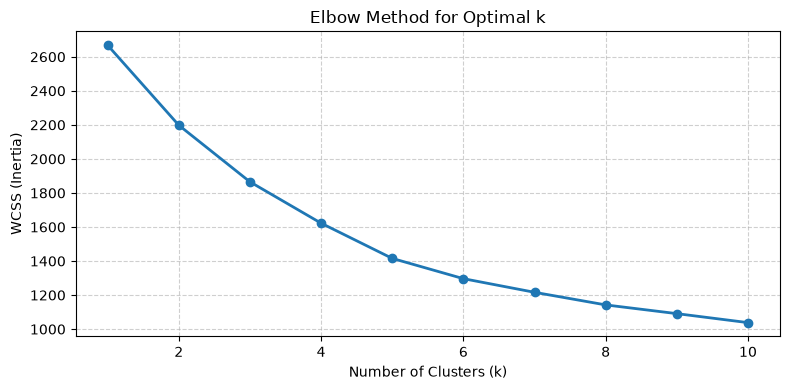

In [2]:
# 4. Calculate WCSS (Within-Cluster Sum of Squares) for k=1 to 10
wcss = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

# 5. Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', color='#1f77b4', linewidth=2)
plt.title('Elbow Method for Optimal k', fontsize=12)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [3]:
# 6. Fit K-Means with optimal k = 3
kmeans_optimal = KMeans(
    n_clusters=3, init='k-means++', random_state=42, n_init=10
)
df['Cluster'] = kmeans_optimal.fit_predict(X_scaled)

# 7. Cluster Profile Breakdown
cluster_summary = df.groupby('Cluster')[features].mean()
cluster_summary['Customer Count'] = df['Cluster'].value_counts()
cluster_summary['Churn Rate (%)'] = (
    df.groupby('Cluster')['Churn'].mean() * 100
).round(2)

display(cluster_summary)

,Total day minutes,Total eve minutes,Total night minutes,Customer service calls,Customer Count,Churn Rate (%)
Cluster,,,,,,
0,202.334104,206.979769,166.596532,3.063584,173,24.28
1,163.927562,166.486926,206.938869,1.120141,283,4.95
2,186.242180,249.832701,217.086256,0.928910,211,18.48


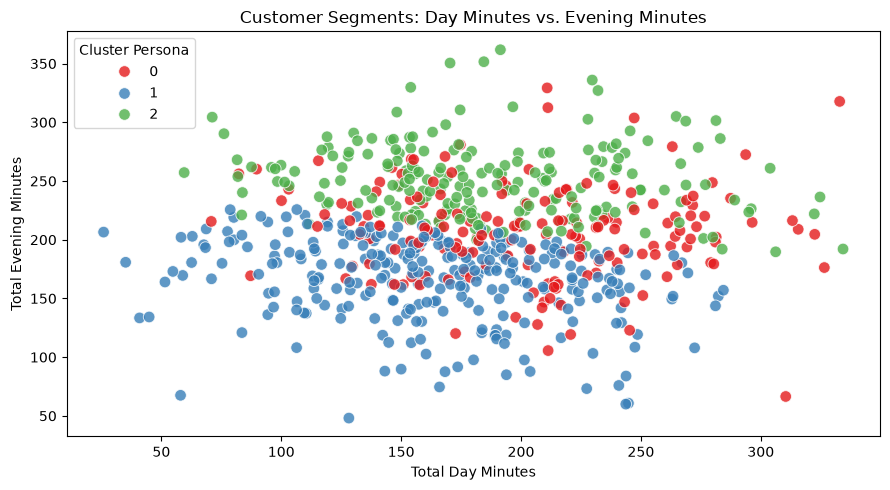

In [4]:
# 8. Scatter plot of clusters
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x='Total day minutes',
    y='Total eve minutes',
    hue='Cluster',
    palette='Set1',
    alpha=0.8,
    s=70,
)

plt.title('Customer Segments: Day Minutes vs. Evening Minutes', fontsize=12)
plt.xlabel('Total Day Minutes')
plt.ylabel('Total Evening Minutes')
plt.legend(title='Cluster Persona')
plt.tight_layout()
plt.show()